# **Beyond the Diagnosis: A Demographic and Behavioral Profiling of Autism Spectrum Traits**

# Phase 1: Executive Summary & Project Objectives

### **Beyond the Binary: A Clinical Data Story**
While many analyses of autism screening datasets default to building basic machine learning classifiers to predict a binary diagnosis (1 or 0), that approach often misses the underlying human complexity of the condition. 

This project intentionally bypasses generic predictive modeling to focus entirely on **deep clinical phenotyping, descriptive analytics, and inferential statistics**. Our objective is to transition raw survey responses into a nuanced behavioral spectrum, answering *how* and *why* Autism Spectrum Disorder (ASD) manifests differently across various populations.

### **Core Objectives**
1. **Domain-Specific Feature Engineering:** Transform standard questionnaire data into advanced clinical metrics, including composite trait burdens, generational cohorts, and "masking" anomaly flags.
2. **Demographic Disparity Analysis:** Investigate systemic healthcare trends, explicitly quantifying the "Gender Presentation Gap" and the rate of delayed diagnoses in adult populations.
3. **Cumulative Risk Validation:** Mathematically isolate individuals with intersecting pre-existing conditions (e.g., genetic history and gestation complications) to calculate precise risk odds ratios.
4. **Statistical Proof:** Move beyond simple visual correlation by using rigorous hypothesis testing (Chi-Square, Mann-Whitney U, Kruskal-Wallis) to separate random statistical noise from true clinical significance.

Ultimately, this notebook serves as an end-to-end clinical data story, transforming raw screening inputs into actionable, medically relevant demographic insights.

### Column Descriptions

| Column Name| Description |
|:-----------|:------------|
|Patient_ID  |Index of the Patients|
| A1         |Do you make eye contact when someone calls your name? ["No","Yes"]|
| A2         |Is it easy for others to get eye contact with you? ["No","Yes"]|
| A3         |Do you point to request something you want? ["No","Yes"]|
| A4         |Do you point to share something interesting with others? ["No","Yes"]|
| A5         |Do you engage in imaginative activities or role-play? ["No","Yes"]|
| A6         |Do you follow others' gaze to see what they're looking at? ["No","Yes"]|
| A7         |Do you try to comfort someone who appears upset? ["No","Yes"]|
| A8         |Would you describe your communication style as typical? ["No","Yes"]|
| A9         |Do you use common gestures (like waving goodbye)? ["No","Yes"]|
| A10        |Do you sometimes stare into space without focus? ["No","Yes"]|
| Sex        |Gender of the individual ["Male","Female"]|
| Age        |Age of the individual in years|
| Age_Group   |Categorization of the individual's age["Child","Adolescent","Adult"]|
| Generational_Cohort |Maps age intervals to generational cohorts (e.g., Gen Z, Millennial, Gen X, Boomer, Gen Alpha)|
| Jaundice   |Indicates if the individual was born with jaundice [1 = "Yes",0 = "No"]|
| Family_ASD |Indicates if an immediate family member has ASD (1 = "Yes", 0 = "No")|
| Risk_Overlap |Describes the combination of background risk factors (e.g., Jaundice, Family ASD)|
| High_Risk_Background |A derived binary indicator of risk based on history|
| Total_Atypical_Trait_Burden |The total score (sum of A1 through A10)|
| Social_Interaction_Score |This score is the sum of A1 (Eye contact when called), A2 (Easy for others to get eye contact), and A6 (Follow others' gaze).|
| Communication_Deficit_Score |This score is derived from the inverse of A3 (Point to request), A4 (Point to share), and A9 (Use common gestures). The inverse is calculated as (1 - A_value), meaning if a trait is present (1), its inverse is 0, indicating no deficit, and if absent (0), its inverse is 1, indicating a potential deficit|
| Behavioral_Atypicality_Score |This score combines the inverse of A5 (Engage in imaginative activities), A7 (Comfort upset person), A8 (Typical communication style), and the direct score of A10 (Stare into space). The inverse calculation (1 - A_value) applies to A5, A7, and A8|
| Social_Comm_Imbalance_Profile |Profile identifying asymmetry between social motivation and communication abilities|
| Eye_Contact_Discordance |Category representing discrepancy between calling name eye contact and easy eye contact, highlighting potential masking|
| Empathy_Imagination_Profile |A category based on empathy and imagination traits|
| Genetic_Severity_Matrix |Categorization of genetic risk based on Family_ASD and symptomatic severity traits|
| Diagnostic_Proximity_Band | A tri-level categorization (Clear Negative, Borderline/Monitor, Clinical Range) based on the total trait burden. This identifies "bubble" patients who sit just below the diagnostic threshold and may require preventative monitoring. |
| Behavioral_Archetype |A qualitative profile representing the individual's behavior|
| Class      |The screening outcome (Yes = Potential ASD, No = Typical)|
| Late_Diagnosis_Flag |Flag for individuals diagnosed/screened at an older age for their group|
| Masking_Proxy_Flag |Indicator suggesting potential masking of symptoms|
| Sub_Clinical_Missed_Flag |Flag identifying potentially missed subclinical cases (undiagnosed but showing high traits)|
| Compensatory_Masking_Flag | A proxy metric isolating older individuals (Age 13+) who exhibit a high global trait burden (5+ traits) but score a perfect 0 on social interaction deficits. This algorithmically flags patients highly likely to be "camouflaging" or masking their autism in social settings. |

### Installation of Libraries

In [1]:
pip install pandas numpy matplotlib seaborn missingno

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Phase 2: Data Architecture & Preprocessing

Before engineering complex behavioral features, we must establish a pristine baseline. Medical screening data is highly susceptible to human error during intake (e.g., typos, phantom categories, and impossible biological outliers). 

**In this phase, we will:**
1. Ingest the raw data and establish our baseline row/column count.
2. Audit for missing values and structural gaps.
3. Harmonize categorical variables to ensure standardized nomenclature.
4. Apply statistical Winsorization (IQR method) to correct biological age anomalies.

### Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno #specialized library to visually check for missing data.
import scipy.stats as stats

sns.set_theme(style="whitegrid", palette="muted")

### Ingestion of dataset

In [3]:
print("--- Step 2.1: Data Ingestion & Initial Audit ---")

# Load the raw dataset
df = pd.read_csv(r"C:\Users\USER\Desktop\python\DAP\data\raw\Autism_Screening_Data_Combined.csv")

# Establish the baseline shape
initial_rows, initial_cols = df.shape
print(f"Initial Dataset Shape: {initial_rows} Patients | {initial_cols} Features")

# Preview the raw state
display(df.head(3))

--- Step 2.1: Data Ingestion & Initial Audit ---
Initial Dataset Shape: 6075 Patients | 15 Features


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Class
0,1,1,0,1,0,0,1,1,0,0,15,m,no,no,NO
1,0,1,1,1,0,1,1,0,1,0,15,m,no,no,NO
2,1,1,1,0,1,1,1,1,1,1,15,f,no,yes,YES


### Inspection of the data

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6075 entries, 0 to 6074
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   A1          6075 non-null   int64 
 1   A2          6075 non-null   int64 
 2   A3          6075 non-null   int64 
 3   A4          6075 non-null   int64 
 4   A5          6075 non-null   int64 
 5   A6          6075 non-null   int64 
 6   A7          6075 non-null   int64 
 7   A8          6075 non-null   int64 
 8   A9          6075 non-null   int64 
 9   A10         6075 non-null   int64 
 10  Age         6075 non-null   int64 
 11  Sex         6075 non-null   object
 12  Jaundice    6075 non-null   object
 13  Family_ASD  6075 non-null   object
 14  Class       6075 non-null   object
dtypes: int64(11), object(4)
memory usage: 712.0+ KB


### Step 2.2: Structural Integrity & Missing Values
In clinical datasets, missing values aren't just empty cells—they represent skipped screening questions which can invalidate composite scoring later on. We use a missing data matrix to visually prove the density of our dataset before proceeding.

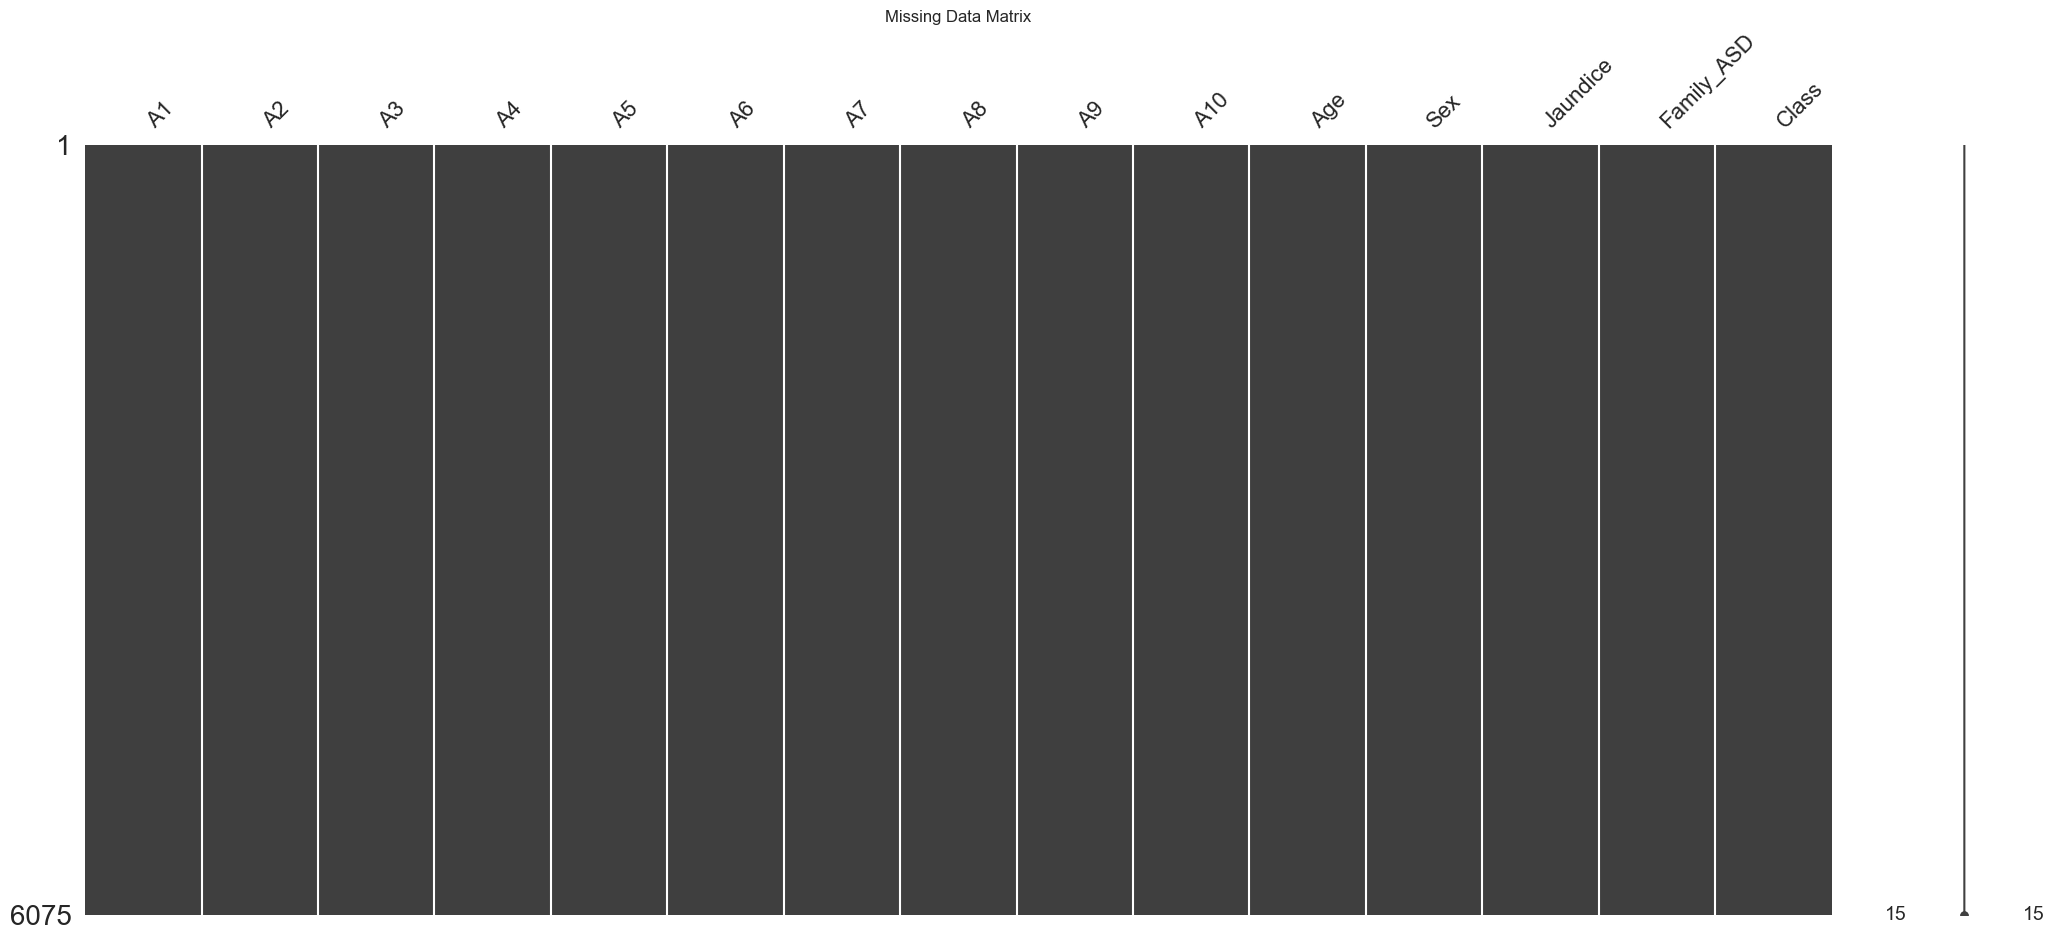

In [5]:
msno.matrix(df)
plt.title("Missing Data Matrix")
plt.show()

In [6]:
display(df.describe())

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age
count,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000
mean,0.693169,0.485103,0.537449,0.547490,0.543868,0.443128,0.497942,0.538436,0.429794,0.599835,19.838025
std,0.461217,0.499819,0.498637,0.497781,0.498113,0.496796,0.500037,0.498562,0.495087,0.489972,14.934246
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
50%,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,19.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,30.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,80.000000


**Key Insights from Initial Inspection:**
1.  **No Missing Values**: All columns have 6075 non-null entries, indicating a complete dataset with no missing values.
2.  **Binary Features (A1-A10)**: The `describe()` output, particularly the min (0) and max (1) values for columns `A1` to `A10`, confirms that these are strictly binary (0 or 1) as expected for Yes/No questions.
3.  **Age Distribution**: The `Age` column shows a wide range (min 4, max 80) with a mean of approximately 19.84 and a median of 19. The standard deviation of 14.93 indicates a significant spread in ages across the dataset.


### Step 2.3: Categorical Harmonization
Survey data often contains "phantom categories" due to inconsistent data entry (e.g., 'm', 'M', 'Male'). We must strictly standardize our categorical columns (`Sex`, `Jaundice`, `Family_ASD`, `Class`) to prevent downstream statistical errors.

In [7]:
print("--- Step 2.3: Categorical Harmonization ---")

# Standardize Sex
df['Sex'] = df['Sex'].replace({'m': 'Male', 'M': 'Male', 'f': 'Female', 'F': 'Female'})

# Standardize binary columns to Yes/No
binary_cols = ['Jaundice', 'Family_ASD']
for col in binary_cols:
    df[col] = df[col].astype(str).str.strip().str.title()
    df[col] = df[col].replace({'1': 'Yes', '0': 'No', 'True': 'Yes', 'False': 'No'})

# Standardize the target variable
df['Class'] = df['Class'].astype(str).str.strip().str.title()

print("Harmonization Complete. Verifying unique values:")
print(f"Sex Categories: {df['Sex'].unique()}")
print(f"Jaundice Categories: {df['Jaundice'].unique()}")
print(f"Class Categories: {df['Class'].unique()}\n")

--- Step 2.3: Categorical Harmonization ---
Harmonization Complete. Verifying unique values:
Sex Categories: ['Male' 'Female']
Jaundice Categories: ['No' 'Yes']
Class Categories: ['No' 'Yes']



### Step 2.4: Biological Outlier Treatment (Age)
When dealing with self-reported ages, users frequently enter typos (e.g., typing "383" instead of "38"). Instead of deleting these records and losing valuable behavioral data, we will apply **Winsorization** using the Interquartile Range (IQR) to cap extreme values at a biologically plausible upper bound.

In [8]:
df['Age'].describe()

count    6075.000000
mean       19.838025
std        14.934246
min         1.000000
25%         5.000000
50%        19.000000
75%        30.000000
max        80.000000
Name: Age, dtype: float64

--- Step 2.4: IQR Outlier Treatment (Age) ---
Detected 14 biologically implausible age outliers (Above 67.5 years).
STATUS: Outliers successfully capped at 67 years.


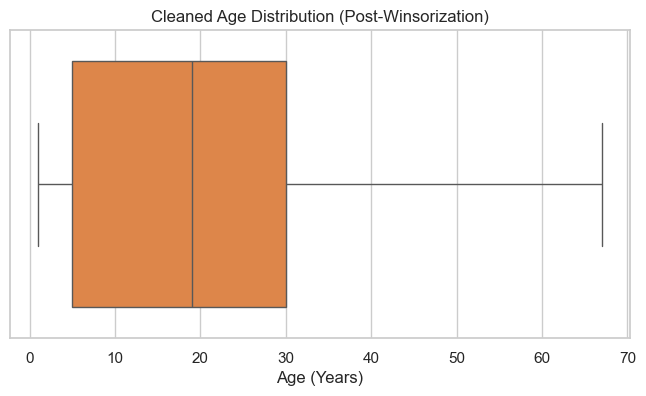

In [9]:
print("--- Step 2.4: IQR Outlier Treatment (Age) ---")

# Define IQR boundaries
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Count anomalies before fixing
outlier_count = len(df[df['Age'] > upper_bound])
print(f"Detected {outlier_count} biologically implausible age outliers (Above {upper_bound} years).")

# Apply Winsorization (cap at upper bound)
df['Age'] = np.where(df['Age'] > upper_bound, upper_bound, df['Age'])

# Ensure clean integer format
df['Age'] = df['Age'].astype(int)

print(f"STATUS: Outliers successfully capped at {int(upper_bound)} years.")

# Visualizing the cleaned distribution
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Age'], color='#F58231')
plt.title('Cleaned Age Distribution (Post-Winsorization)')
plt.xlabel('Age (Years)')
plt.show()

### Step 2.5: Duplicate Audit & Binary Validation
The final step in our preprocessing architecture is to check for system errors:
1. **Binary Integrity:** Are we absolutely certain that the survey responses (A1 through A10) only contain `0`s and `1`s? If a typo introduced a `2` or `3`, our composite scoring algorithms in the next phase will break.

In [10]:
print("--- Step 2.5: Final Integrity Audit ---")

# 1. Binary Validation for A1-A10
a_columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']
binary_violation = False

for col in a_columns:
    # Check if any value is NOT 0 or 1
    if not df[col].isin([0, 1, '0', '1']).all():
        binary_violation = True
        print(f"WARNING: Non-binary value detected in {col}!")

if not binary_violation:
    print("STATUS: Binary integrity confirmed. A1-A10 contain only 0s and 1s.")

print("\n--- PHASE 2 COMPLETE: Data is Pristine ---")

--- Step 2.5: Final Integrity Audit ---
STATUS: Binary integrity confirmed. A1-A10 contain only 0s and 1s.

--- PHASE 2 COMPLETE: Data is Pristine ---


### Printing the updated dataframe

In [11]:
df.head(10)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Class
0,1,1,0,1,0,0,1,1,0,0,15,Male,No,No,No
1,0,1,1,1,0,1,1,0,1,0,15,Male,No,No,No
2,1,1,1,0,1,1,1,1,1,1,15,Female,No,Yes,Yes
3,1,1,1,1,1,1,1,1,0,0,16,Female,No,No,Yes
4,1,1,1,1,1,1,1,1,1,1,15,Female,No,No,Yes
5,0,1,1,1,0,1,1,0,1,0,14,Male,No,No,No
6,1,0,0,0,1,0,0,1,0,1,14,Female,No,No,No
7,1,0,0,0,1,0,0,1,0,1,12,Male,No,No,No
8,1,0,0,0,1,0,0,1,0,1,15,Female,No,No,No
9,0,1,1,1,0,1,1,0,1,0,12,Female,No,No,No


# Phase 3: Foundational Feature Engineering (The 7-Tier Architecture)

With our baseline data pristine, we now transition from generic survey data into **Clinical Phenotyping**. A simple sum of positive answers is not enough to understand the autism spectrum. We must engineer features that capture relational imbalances, internal behavioral contradictions, and genetic penetrance.

**In this phase, we will:**
1. Engineer Advanced Relational Metrics (Imbalance Profiles & Discordance).
2. Engineer Anomaly Flags to audit ground-truth diagnoses.
3. Reorganize the entire dataset into an industry-standard **7-Tier Clinical Architecture** (Identifiers $\rightarrow$ Demographics $\rightarrow$ History $\rightarrow$ Math $\rightarrow$ Nuance $\rightarrow$ Clusters $\rightarrow$ Outcomes).

### 1. Identifiers & Raw Behavioral Inputs (The Ground Truth)
These are the unfiltered survey responses that everything else is built upon.

In [12]:
# 1. Create the Patient_ID column
df.insert(0, 'Patient_ID', ['PT_' + str(i).zfill(4) for i in range(1, len(df) + 1)])

# 2. Set it as the index immediately
df.set_index('Patient_ID', inplace=True)

# 3. Verify the changes
print("Index and first few columns:")
display(df.head())

Index and first few columns:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Class
Patient_ID,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,15,Male,No,No,No
PT_0002,0,1,1,1,0,1,1,0,1,0,15,Male,No,No,No
PT_0003,1,1,1,0,1,1,1,1,1,1,15,Female,No,Yes,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,16,Female,No,No,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,15,Female,No,No,Yes


### 2. Core Demographics (Who are they?)
We establish the biological and sociological identity of the patient before looking at their medical history.

In [13]:
# Find exactly where 'Age' is located dynamically
age_idx = df.columns.tolist().index('Age')

#### Age Grouping

To facilitate a more granular analysis of how ASD traits manifest across different developmental stages, a new categorical feature called `Age_Group` was engineered. This feature categorizes individuals into 'Child', 'Adolescent', and 'Adult' based on their 'Age'.

**Creation Process:**

The `Age_Group` was created using the `pd.cut()` function, which bins the numerical 'Age' column into predefined intervals. The following bins and labels were used:
-   **Children:** Ages 0 to 12 years
-   **Adolescents:** Ages 13 to 18 years
-   **Adults:** Ages 19 to 81 years (considering the maximum age in the dataset is 80).

**Rationale:**

Categorizing age into these groups allows for a more insightful analysis of behavioral and demographic patterns. ASD presentations can vary significantly with age, and this grouping helps in identifying specific challenges or characteristics prevalent in different life stages. For instance, certain social or communication traits might be more pronounced or interpreted differently in a child compared to an adult.


This distribution indicates a substantial representation across all major developmental stages, allowing for comprehensive comparative analysis.

In [14]:
# Define age bins and labels
age_bins = [0, 12, 18, 81]
age_labels = ['Child', 'Adolescent', 'Adult']

# 1. Get the integer index of the 'Age' column dynamically
age_idx = df.columns.get_loc('Age')

# 2. Calculate the bins AND insert the column in a single step
df.insert(
    loc=age_idx + 1,
    column='Age_Group',
    value=pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)
)

print("Distribution of 'Age_Group':")
display(df['Age_Group'].value_counts())

Distribution of 'Age_Group':


Age_Group
Adult         3094
Child         2303
Adolescent     678
Name: count, dtype: int64

### Granular Generational Cohorts

In [15]:
# Define age bins and labels for Generational_Cohort
age_bins_gen = [0, 12, 26, 42, 58, df['Age'].max() + 1]
age_labels_gen = ["Gen Alpha (Child)", "Gen Z", "Millennial", "Gen X", "Boomer"]

# Ensure age_idx is defined (if running this in a new cell)
age_idx = df.columns.get_loc('Age')

# Insert the new column immediately after 'Age_Group' (which is at age_idx + 1)
df.insert(
    loc=age_idx + 2,
    column='Generational_Cohort',
    value=pd.cut(df['Age'], bins=age_bins_gen, labels=age_labels_gen, right=False)
)

print("Distribution of 'Generational_Cohort':")
display(df['Generational_Cohort'].value_counts())

print("First few rows with 'Generational_Cohort':")
display(df.head())

Distribution of 'Generational_Cohort':


Generational_Cohort
Gen Alpha (Child)    2159
Gen Z                1990
Millennial           1315
Gen X                 535
Boomer                 76
Name: count, dtype: int64

First few rows with 'Generational_Cohort':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Age_Group,Generational_Cohort,Sex,Jaundice,Family_ASD,Class
Patient_ID,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,15,Adolescent,Gen Z,Male,No,No,No
PT_0002,0,1,1,1,0,1,1,0,1,0,15,Adolescent,Gen Z,Male,No,No,No
PT_0003,1,1,1,0,1,1,1,1,1,1,15,Adolescent,Gen Z,Female,No,Yes,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,16,Adolescent,Gen Z,Female,No,No,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,15,Adolescent,Gen Z,Female,No,No,Yes


In [16]:
print("Demographic cohorts successfully placed after 'Age'.")
print("Current columns:", df.columns.tolist())

Demographic cohorts successfully placed after 'Age'.
Current columns: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age', 'Age_Group', 'Generational_Cohort', 'Sex', 'Jaundice', 'Family_ASD', 'Class']


### 3. Medical & Genetic Background (What is their history?)
These are the pre-existing risk factors.

In [17]:
family_asd_idx = df.columns.get_loc('Family_ASD')

# Check for the actual column names you used earlier
if 'Jaundice' in df.columns and 'Family_ASD' in df.columns:
    conditions = [
        (df['Jaundice'] == 'Yes') & (df['Family_ASD'] == 'Yes'),
        (df['Jaundice'] == 'Yes') & (df['Family_ASD'] == 'No'),
        (df['Jaundice'] == 'No') & (df['Family_ASD'] == 'Yes'),
        (df['Jaundice'] == 'No') & (df['Family_ASD'] == 'No')
    ]
    choices = ['Both (High Risk)', 'Jaundice Only', 'Family ASD Only', 'Neither']

    # Create the new overlap column
    risk_overlap_values = np.select(conditions, choices, default='Unknown')

    # Insert the new column after 'Family_ASD'
    df.insert(loc=family_asd_idx + 1, column='Risk_Overlap', value=risk_overlap_values)

    print("First few rows with 'Risk_Overlap':")
    display(df.head())
else:
    print("ERROR: Could not find 'Jaundice' or 'Family_ASD' in the dataset.")

First few rows with 'Risk_Overlap':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Age_Group,Generational_Cohort,Sex,Jaundice,Family_ASD,Risk_Overlap,Class
Patient_ID,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,15,Adolescent,Gen Z,Male,No,No,Neither,No
PT_0002,0,1,1,1,0,1,1,0,1,0,15,Adolescent,Gen Z,Male,No,No,Neither,No
PT_0003,1,1,1,0,1,1,1,1,1,1,15,Adolescent,Gen Z,Female,No,Yes,Family ASD Only,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,16,Adolescent,Gen Z,Female,No,No,Neither,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,15,Adolescent,Gen Z,Female,No,No,Neither,Yes


#### Risk Profiling Flags

##### High_Risk_Background Feature Explanation

The `High_Risk_Background` feature is a new binary flag (0 or 1) engineered to identify individuals who present with a combination of two specific risk factors: a history of `Jaundice` and a `Family_ASD` history.

This feature is created based on the following condition:
- If an individual has both `Jaundice` = 'Yes' and `Family_ASD` = 'Yes', then `High_Risk_Background` is set to `1`.
- Otherwise, `High_Risk_Background` is set to `0`.

The rationale behind this feature is to create a composite indicator for a potentially elevated background risk of ASD. By combining these two medical history factors, we can investigate if the presence of both correlates more strongly with ASD traits or diagnosis than each factor individually. This provides a more nuanced approach to risk profiling within the dataset.

In [18]:
risk_overlap_idx = df.columns.get_loc('Risk_Overlap')

# Create a binary High_Risk_Background feature
df.insert(
    loc=risk_overlap_idx + 1,
    column='High_Risk_Background',
    value=((df['Jaundice'] == 'Yes') & (df['Family_ASD'] == 'Yes')).astype(int)
)

print("Distribution of 'High_Risk_Background':")
display(df['High_Risk_Background'].value_counts())

print("Displaying first 10 rows with new features:")
display(df.head(10))

Distribution of 'High_Risk_Background':


High_Risk_Background
0    5808
1     267
Name: count, dtype: int64

Displaying first 10 rows with new features:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Age_Group,Generational_Cohort,Sex,Jaundice,Family_ASD,Risk_Overlap,High_Risk_Background,Class
Patient_ID,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,15,Adolescent,Gen Z,Male,No,No,Neither,0,No
PT_0002,0,1,1,1,0,1,1,0,1,0,15,Adolescent,Gen Z,Male,No,No,Neither,0,No
PT_0003,1,1,1,0,1,1,1,1,1,1,15,Adolescent,Gen Z,Female,No,Yes,Family ASD Only,0,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,16,Adolescent,Gen Z,Female,No,No,Neither,0,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,15,Adolescent,Gen Z,Female,No,No,Neither,0,Yes
PT_0006,0,1,1,1,0,1,1,0,1,0,14,Adolescent,Gen Z,Male,No,No,Neither,0,No
PT_0007,1,0,0,0,1,0,0,1,0,1,14,Adolescent,Gen Z,Female,No,No,Neither,0,No
PT_0008,1,0,0,0,1,0,0,1,0,1,12,Child,Gen Z,Male,No,No,Neither,0,No
PT_0009,1,0,0,0,1,0,0,1,0,1,15,Adolescent,Gen Z,Female,No,No,Neither,0,No


### 4. Macro-Level Severity Scores (The Math)
These are your foundational, continuous metrics.

#### Total_Atypical_Trait_Burden
A global severity score (0-10) representing the sum of all atypical behavioral and developmental traits exhibited by the patient.

In [19]:
high_risk_idx = df.columns.get_loc('High_Risk_Background')

# Creating Total_Atypical_Trait_Burden
df.insert(
    loc=high_risk_idx + 1,
    column='Total_Atypical_Trait_Burden',
    value=(1 - df['A1']) + (1 - df['A2']) + (1 - df['A3']) +
          (1 - df['A4']) + (1 - df['A5']) + (1 - df['A6']) +
          (1 - df['A7']) + (1 - df['A8']) + (1 - df['A9']) +
          df['A10']
)

# Ensure 'Class' column is 'Yes'/'No' strings for the palette in the next cell
df['Class'] = df['Class'].replace({1: 'Yes', 0: 'No'})

print("Distribution of 'Total_Atypical_Trait_Burden':")
display(df['Total_Atypical_Trait_Burden'].value_counts().sort_index())

print("First few rows with 'Total_Atypical_Trait_Burden':")
display(df.head())

Distribution of 'Total_Atypical_Trait_Burden':


Total_Atypical_Trait_Burden
0      51
1     384
2     644
3     775
4     882
5     835
6     833
7     813
8     510
9     282
10     66
Name: count, dtype: int64

First few rows with 'Total_Atypical_Trait_Burden':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Age_Group,Generational_Cohort,Sex,Jaundice,Family_ASD,Risk_Overlap,High_Risk_Background,Total_Atypical_Trait_Burden,Class
Patient_ID,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,15,Adolescent,Gen Z,Male,No,No,Neither,0,4,No
PT_0002,0,1,1,1,0,1,1,0,1,0,15,Adolescent,Gen Z,Male,No,No,Neither,0,3,No
PT_0003,1,1,1,0,1,1,1,1,1,1,15,Adolescent,Gen Z,Female,No,Yes,Family ASD Only,0,2,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,16,Adolescent,Gen Z,Female,No,No,Neither,0,1,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,15,Adolescent,Gen Z,Female,No,No,Neither,0,1,Yes


#### Composite Scores
##### Creating composite behavioral metrics to add analytical depth

To enhance the analytical depth of our dataset, we have created several composite scores by aggregating related binary behavioral traits. These scores move beyond individual 'Yes'/'No' responses to provide a more holistic view of different aspects of the autism spectrum traits. These additions are reflected in a conceptual 'Data Dictionary 2.0'.

1.  **Social_Interaction_Score (Range: 0-3)**:
    *   **Calculation**: This score is the sum of `A1` (Eye contact when called), `A2` (Easy for others to get eye contact), and `A6` (Follow others' gaze).
    *   **Rationale**: A higher score indicates a greater presence of social interaction behaviors. This composite score aims to quantify an individual's engagement in fundamental social interaction cues, which are often impacted in ASD.

2.  **Communication_Deficit_Score (Range: 0-3)**:
    *   **Calculation**: This score is derived from the inverse of `A3` (Point to request), `A4` (Point to share), and `A9` (Use common gestures). The inverse is calculated as `(1 - A_value)`, meaning if a trait is present (1), its inverse is 0, indicating no deficit, and if absent (0), its inverse is 1, indicating a potential deficit.
    *   **Rationale**: A higher score here suggests a greater deficit in typical communication behaviors. This score attempts to capture the challenges individuals might face in using conventional non-verbal communication methods.

3.  **Behavioral_Atypicality_Score (Range: 0-4)**:
    *   **Calculation**: This score combines the inverse of `A5` (Engage in imaginative activities), `A7` (Comfort upset person), `A8` (Typical communication style), and the direct score of `A10` (Stare into space). The inverse calculation `(1 - A_value)` applies to A5, A7, and A8.
    *   **Rationale**: This score aims to quantify the presence of behaviors often considered atypical or challenging within the context of ASD. A higher score implies more pronounced atypical behavioral patterns.

These composite scores offer a richer, more continuous representation of complex behavioral dimensions than their individual binary components, allowing for more nuanced analysis of trait presentation across different demographic groups. For reference, the first 20 rows of the DataFrame, including these newly engineered scores, have been displayed in the previous output.

#### Social_Interaction_Score
A composite metric evaluating deficits in social awareness and engagement (based on eye contact, sharing interests, and social smiling).

In [20]:
total_atypical_trait_burden_idx = df.columns.get_loc('Total_Atypical_Trait_Burden')

# Create the Social_Interaction_Score
df.insert(
    loc=total_atypical_trait_burden_idx + 1,
    column='Social_Interaction_Score',
    value=df['A1'] + df['A2'] + df['A6']
)

print("First few rows with 'Social_Interaction_Score':")
display(df.head())

First few rows with 'Social_Interaction_Score':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Age_Group,Generational_Cohort,Sex,Jaundice,Family_ASD,Risk_Overlap,High_Risk_Background,Total_Atypical_Trait_Burden,Social_Interaction_Score,Class
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,Adolescent,Gen Z,Male,No,No,Neither,0,4,2,No
PT_0002,0,1,1,1,0,1,1,0,1,0,...,Adolescent,Gen Z,Male,No,No,Neither,0,3,2,No
PT_0003,1,1,1,0,1,1,1,1,1,1,...,Adolescent,Gen Z,Female,No,Yes,Family ASD Only,0,2,3,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,...,Adolescent,Gen Z,Female,No,No,Neither,0,1,3,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,...,Adolescent,Gen Z,Female,No,No,Neither,0,1,3,Yes


#### Communication_Deficit_Score
A composite metric quantifying challenges in expressive or receptive communication, including conversational tracking.

In [21]:
social_interaction_score_idx = df.columns.get_loc('Social_Interaction_Score')

# Create the Communication_Deficit_Score
df.insert(
    loc=social_interaction_score_idx + 1,
    column='Communication_Deficit_Score',
    value=(1 - df['A3']) + (1 - df['A4']) + (1 - df['A9'])
)

print("First few rows with 'Communication_Deficit_Score':")
display(df.head())

First few rows with 'Communication_Deficit_Score':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Generational_Cohort,Sex,Jaundice,Family_ASD,Risk_Overlap,High_Risk_Background,Total_Atypical_Trait_Burden,Social_Interaction_Score,Communication_Deficit_Score,Class
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,Gen Z,Male,No,No,Neither,0,4,2,2,No
PT_0002,0,1,1,1,0,1,1,0,1,0,...,Gen Z,Male,No,No,Neither,0,3,2,0,No
PT_0003,1,1,1,0,1,1,1,1,1,1,...,Gen Z,Female,No,Yes,Family ASD Only,0,2,3,1,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,...,Gen Z,Female,No,No,Neither,0,1,3,1,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,...,Gen Z,Female,No,No,Neither,0,1,3,0,Yes


#### Behavioral_Atypicality_Score
A metric tracking the presence of restricted, repetitive, or highly systematized behavioral patterns.

In [22]:
communication_deficit_score_idx = df.columns.get_loc('Communication_Deficit_Score')

# Create the Behavioral_Atypicality_Score
df.insert(
    loc=communication_deficit_score_idx + 1,
    column='Behavioral_Atypicality_Score',
    value=(1 - df['A5']) + (1 - df['A7']) + (1 - df['A8']) + df['A10']
)

print("First few rows with 'Behavioral_Atypicality_Score':")
display(df.head())

First few rows with 'Behavioral_Atypicality_Score':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Sex,Jaundice,Family_ASD,Risk_Overlap,High_Risk_Background,Total_Atypical_Trait_Burden,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Class
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,Male,No,No,Neither,0,4,2,2,1,No
PT_0002,0,1,1,1,0,1,1,0,1,0,...,Male,No,No,Neither,0,3,2,0,2,No
PT_0003,1,1,1,0,1,1,1,1,1,1,...,Female,No,Yes,Family ASD Only,0,2,3,1,1,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,...,Female,No,No,Neither,0,1,3,1,0,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,...,Female,No,No,Neither,0,1,3,0,1,Yes


### 5. Micro-Variance & Clinical Imbalance (The Nuance)
These are your advanced relational metrics built in our final feature engineering step.

#### Social_Comm_Imbalance_Profile
Evaluates the ratio between social motivation and communication ability, identifying patients who are "Socially Motivated but Communication Blocked" vs. "Capable but Socially Withdrawn."

In [23]:
behavioral_atypicality_score_idx = df.columns.get_loc('Behavioral_Atypicality_Score')

conditions = [
    (df['Social_Interaction_Score'] == 3) & (df['Communication_Deficit_Score'] == 3),
    (df['Social_Interaction_Score'] == 0) & (df['Communication_Deficit_Score'] == 0)
]

choices = [
    "Socially Motivated but Communication Blocked",
    "Capable but Socially Withdrawn"
]

df.insert(
    loc=behavioral_atypicality_score_idx + 1,
    column='Social_Comm_Imbalance_Profile',
    value=np.select(
        condlist=conditions,
        choicelist=choices,
        default="Other Profile"
    )
)

print("Distribution of 'Social_Comm_Imbalance_Profile':")
display(df['Social_Comm_Imbalance_Profile'].value_counts())

print("First few rows with 'Social_Comm_Imbalance_Profile':")
display(df.head())

Distribution of 'Social_Comm_Imbalance_Profile':


Social_Comm_Imbalance_Profile
Other Profile                                   5969
Socially Motivated but Communication Blocked      59
Capable but Socially Withdrawn                    47
Name: count, dtype: int64

First few rows with 'Social_Comm_Imbalance_Profile':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Jaundice,Family_ASD,Risk_Overlap,High_Risk_Background,Total_Atypical_Trait_Burden,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Social_Comm_Imbalance_Profile,Class
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,No,No,Neither,0,4,2,2,1,Other Profile,No
PT_0002,0,1,1,1,0,1,1,0,1,0,...,No,No,Neither,0,3,2,0,2,Other Profile,No
PT_0003,1,1,1,0,1,1,1,1,1,1,...,No,Yes,Family ASD Only,0,2,3,1,1,Other Profile,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,...,No,No,Neither,0,1,3,1,0,Other Profile,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,...,No,No,Neither,0,1,3,0,1,Other Profile,Yes


#### Eye_Contact_Discordance
Flags internal behavioral contradictions by comparing spontaneous eye contact with eye contact when called. It helps identify context-dependent masking.

In [24]:
social_comm_imbalance_profile_idx = df.columns.get_loc('Social_Comm_Imbalance_Profile')

conditions = [
    (df['A1'] == 1) & (df['A2'] == 1),
    (df['A1'] == 0) & (df['A2'] == 0),
    (df['A1'] != df['A2'])
]

choices = [
    "Fully Typical",
    "Global Deficit",
    "Discordant / Masked"
]

df.insert(
    loc=social_comm_imbalance_profile_idx + 1,
    column='Eye_Contact_Discordance',
    value=np.select(
        condlist=conditions,
        choicelist=choices,
        default="Other"
    )
)

print("Distribution of 'Eye_Contact_Discordance':")
display(df['Eye_Contact_Discordance'].value_counts())

print("First few rows with 'Eye_Contact_Discordance':")
display(df.head())

Distribution of 'Eye_Contact_Discordance':


Eye_Contact_Discordance
Discordant / Masked    2722
Fully Typical          2218
Global Deficit         1135
Name: count, dtype: int64

First few rows with 'Eye_Contact_Discordance':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Family_ASD,Risk_Overlap,High_Risk_Background,Total_Atypical_Trait_Burden,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Social_Comm_Imbalance_Profile,Eye_Contact_Discordance,Class
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,No,Neither,0,4,2,2,1,Other Profile,Fully Typical,No
PT_0002,0,1,1,1,0,1,1,0,1,0,...,No,Neither,0,3,2,0,2,Other Profile,Discordant / Masked,No
PT_0003,1,1,1,0,1,1,1,1,1,1,...,Yes,Family ASD Only,0,2,3,1,1,Other Profile,Fully Typical,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,...,No,Neither,0,1,3,1,0,Other Profile,Fully Typical,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,...,No,Neither,0,1,3,0,1,Other Profile,Fully Typical,Yes


#### Empathy_Imagination_Profile

In [25]:
eye_contact_discordance_idx = df.columns.get_loc('Eye_Contact_Discordance')

def get_empathy_imagination_profile(row):
    # 'No' for A7 means 0 (struggles with empathy)
    # 'Yes' for A5 means 1 (engages in imagination)
    if row['A7'] == 0 and row['A5'] == 1:
        return 'Isolated Emotional Deficit'
    # 'No' for A7 means 0 (struggles with empathy)
    # 'No' for A5 means 0 (does not engage in imagination)
    elif row['A7'] == 0 and row['A5'] == 0:
        return 'Global Cognitive/Emotional Deficit'
    else:
        return 'Other' # All other combinations (e.g., A7=1, A5=1; A7=1, A5=0)

df.insert(
    loc=eye_contact_discordance_idx + 1,
    column='Empathy_Imagination_Profile',
    value=df.apply(get_empathy_imagination_profile, axis=1)
)

print("Distribution of 'Empathy_Imagination_Profile':")
display(df['Empathy_Imagination_Profile'].value_counts())

print("First few rows with 'Empathy_Imagination_Profile':")
display(df.head())

Distribution of 'Empathy_Imagination_Profile':


Empathy_Imagination_Profile
Other                                 3025
Global Cognitive/Emotional Deficit    1763
Isolated Emotional Deficit            1287
Name: count, dtype: int64

First few rows with 'Empathy_Imagination_Profile':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Risk_Overlap,High_Risk_Background,Total_Atypical_Trait_Burden,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Social_Comm_Imbalance_Profile,Eye_Contact_Discordance,Empathy_Imagination_Profile,Class
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,Neither,0,4,2,2,1,Other Profile,Fully Typical,Other,No
PT_0002,0,1,1,1,0,1,1,0,1,0,...,Neither,0,3,2,0,2,Other Profile,Discordant / Masked,Other,No
PT_0003,1,1,1,0,1,1,1,1,1,1,...,Family ASD Only,0,2,3,1,1,Other Profile,Fully Typical,Other,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,...,Neither,0,1,3,1,0,Other Profile,Fully Typical,Other,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,...,Neither,0,1,3,0,1,Other Profile,Fully Typical,Other,Yes


#### Genetic_Severity_Matrix (Categorical)

The `Genetic_Severity_Matrix` feature is engineered to explore the relationship between family history of ASD and the severity of an individual's atypical traits. This categorical feature aims to provide insight into whether a genetic predisposition correlates with the intensity of trait presentation.

**Calculation Details:**
This feature combines `Family_ASD` (indicating a family history of ASD) with `Total_Atypical_Trait_Burden` (a score from 0 to 10 representing the number of atypical traits).

-   **'High Genetic Penetrance'**: Assigned to individuals with `Family_ASD` = 'Yes' (1) and a `Total_Atypical_Trait_Burden` of 7 or higher. This suggests a strong manifestation of traits in the presence of a family history.
-   **'Low Genetic Penetrance'**: Assigned to individuals with `Family_ASD` = 'Yes' (1) and a `Total_Atypical_Trait_Burden` of 3 or lower. This indicates fewer atypical traits despite a family history.
-   **'Intermediate Genetic Penetrance'**: Assigned to individuals with `Family_ASD` = 'Yes' (1) and a `Total_Atypical_Trait_Burden` between 4 and 6 (inclusive). This represents a moderate level of trait presentation with a family history.
-   **'No Family History'**: Assigned to individuals with `Family_ASD` = 'No' (0), regardless of their `Total_Atypical_Trait_Burden`. This serves as a baseline group without known genetic predisposition from immediate family.

This feature will be instrumental in analyzing whether doctors are biased towards diagnosing individuals with a family history faster, or if these individuals genuinely exhibit more severe traits.

In [26]:
empathy_imagination_profile_idx = df.columns.get_loc('Empathy_Imagination_Profile')

# Ensure Family_ASD is numerical (0/1) before proceeding with conditions
if df['Family_ASD'].dtype == 'object':
    df['Family_ASD'] = df['Family_ASD'].replace({'Yes': 1, 'No': 0}).astype(int)

conditions_genetic_severity = [
    (df['Family_ASD'] == 1) & (df['Total_Atypical_Trait_Burden'] >= 7),
    (df['Family_ASD'] == 1) & (df['Total_Atypical_Trait_Burden'] <= 3),
    (df['Family_ASD'] == 1) & (df['Total_Atypical_Trait_Burden'] > 3) & (df['Total_Atypical_Trait_Burden'] < 7),
    (df['Family_ASD'] == 0)
]

choices_genetic_severity = [
    "High Genetic Penetrance",
    "Low Genetic Penetrance",
    "Intermediate Genetic Penetrance",
    "No Family History"
]

df.insert(
    loc=empathy_imagination_profile_idx + 1,
    column='Genetic_Severity_Matrix',
    value=np.select(
        condlist=conditions_genetic_severity,
        choicelist=choices_genetic_severity,
        default="Unknown" # Should not be hit if all conditions are covered
    )
)

print("Distribution of 'Genetic_Severity_Matrix':")
display(df['Genetic_Severity_Matrix'].value_counts())

print("First few rows with 'Genetic_Severity_Matrix':")
display(df.head())

Distribution of 'Genetic_Severity_Matrix':


C:\Users\USER\AppData\Local\Temp\ipykernel_11276\3264834530.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Family_ASD'] = df['Family_ASD'].replace({'Yes': 1, 'No': 0}).astype(int)


Genetic_Severity_Matrix
No Family History                  4953
Intermediate Genetic Penetrance     456
Low Genetic Penetrance              434
High Genetic Penetrance             232
Name: count, dtype: int64

First few rows with 'Genetic_Severity_Matrix':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,High_Risk_Background,Total_Atypical_Trait_Burden,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Social_Comm_Imbalance_Profile,Eye_Contact_Discordance,Empathy_Imagination_Profile,Genetic_Severity_Matrix,Class
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,0,4,2,2,1,Other Profile,Fully Typical,Other,No Family History,No
PT_0002,0,1,1,1,0,1,1,0,1,0,...,0,3,2,0,2,Other Profile,Discordant / Masked,Other,No Family History,No
PT_0003,1,1,1,0,1,1,1,1,1,1,...,0,2,3,1,1,Other Profile,Fully Typical,Other,Low Genetic Penetrance,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,...,0,1,3,1,0,Other Profile,Fully Typical,Other,No Family History,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,...,0,1,3,0,1,Other Profile,Fully Typical,Other,No Family History,Yes


### 6. Final Categorical Phenotyping (The Clusters)
This is the ultimate summary of the patient's presentation.

#### Behavioral_Archtype
A categorical cluster (e.g., "Severe Global Delay", "Mild/Typical Presentation") that synthesizes the patient's entire composite profile into a single recognizable clinical phenotype.

In [27]:
genetic_severity_matrix_idx = df.columns.get_loc('Genetic_Severity_Matrix')

# First, we define a list of conditions (our logical thresholds)
# - Social_Interaction_Score: Range 0-3 (Higher = Stronger social skills)
# - Communication_Deficit_Score: Range 0-3 (Higher = Greater deficit)
# - Behavioral_Atypicality_Score: Range 0-4 (Higher = More atypical/ASD-like)

conditions = [
    # Archetype 1: Severe Global Delay
    # Patient has poor social skills AND severe communication deficits AND high atypicality
    (df['Social_Interaction_Score'] <= 1) &
    (df['Communication_Deficit_Score'] >= 2) &
    (df['Behavioral_Atypicality_Score'] >= 2),

    # Archetype 2: Communication Impaired (But socially engaged)
    # Patient struggles with pointing/gestures, but still makes eye contact and follows gaze
    (df['Communication_Deficit_Score'] >= 2) &
    (df['Social_Interaction_Score'] >= 2),

    # Archetype 3: Socially Withdrawn (But communicative)
    # Patient can point and use gestures, but avoids eye contact and joint attention
    (df['Social_Interaction_Score'] <= 1) &
    (df['Communication_Deficit_Score'] <= 1),

    # Archetype 4: Highly Atypical / Restricted
    # Patient might communicate and socialize okay, but exhibits high atypical traits (staring, no empathy/roleplay)
    (df['Behavioral_Atypicality_Score'] >= 3) &
    (df['Communication_Deficit_Score'] <= 1)
]

# Next, we define the exact text labels corresponding to the conditions above
# The order of this list MUST match the order of the conditions list
choices = [
    "Severe Global Delay",
    "Communication Impaired",
    "Socially Withdrawn",
    "Highly Atypical Presentation"
]

# Apply np.select to create the new column.
# The 'default' parameter catches anyone who doesn't trigger the severe thresholds above.
df.insert(
    loc=genetic_severity_matrix_idx + 1,
    column='Behavioral_Archetype',
    value=np.select(
        condlist=conditions,
        choicelist=choices,
        default="Mild/Typical Presentation"
    )
)

print("Distribution of 'Behavioral_Archetype':")
display(df['Behavioral_Archetype'].value_counts())

print("First few rows with 'Behavioral_Archetype':")
display(df.head())

Distribution of 'Behavioral_Archetype':


Behavioral_Archetype
Mild/Typical Presentation       2135
Severe Global Delay             1591
Communication Impaired          1094
Socially Withdrawn               870
Highly Atypical Presentation     385
Name: count, dtype: int64

First few rows with 'Behavioral_Archetype':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Total_Atypical_Trait_Burden,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Social_Comm_Imbalance_Profile,Eye_Contact_Discordance,Empathy_Imagination_Profile,Genetic_Severity_Matrix,Behavioral_Archetype,Class
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,4,2,2,1,Other Profile,Fully Typical,Other,No Family History,Communication Impaired,No
PT_0002,0,1,1,1,0,1,1,0,1,0,...,3,2,0,2,Other Profile,Discordant / Masked,Other,No Family History,Mild/Typical Presentation,No
PT_0003,1,1,1,0,1,1,1,1,1,1,...,2,3,1,1,Other Profile,Fully Typical,Other,Low Genetic Penetrance,Mild/Typical Presentation,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,...,1,3,1,0,Other Profile,Fully Typical,Other,No Family History,Mild/Typical Presentation,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,...,1,3,0,1,Other Profile,Fully Typical,Other,No Family History,Mild/Typical Presentation,Yes


### 7. Outcomes & Healthcare Proxies (The Destination)
In machine learning and analytics, the "Target" variable and its associated outcome flags ALWAYS go at the very end (far right) of the dataset.

#### Class

In [28]:
if 'Class' in df.columns:
    # Store the 'Class' column
    class_column = df['Class']
    # Drop the 'Class' column from its current position
    df = df.drop(columns=['Class'])
    # Append the 'Class' column to the end of the DataFrame
    df['Class'] = class_column
    print("Class column successfully moved to the end of the DataFrame.")
    print("Updated columns:", df.columns.tolist()[-5:]) # Display last 5 columns to show 'Class'
    display(df.head())
else:
    print("Error: 'Class' column not found in the DataFrame.")

Class column successfully moved to the end of the DataFrame.
Updated columns: ['Eye_Contact_Discordance', 'Empathy_Imagination_Profile', 'Genetic_Severity_Matrix', 'Behavioral_Archetype', 'Class']


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Total_Atypical_Trait_Burden,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Social_Comm_Imbalance_Profile,Eye_Contact_Discordance,Empathy_Imagination_Profile,Genetic_Severity_Matrix,Behavioral_Archetype,Class
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,4,2,2,1,Other Profile,Fully Typical,Other,No Family History,Communication Impaired,No
PT_0002,0,1,1,1,0,1,1,0,1,0,...,3,2,0,2,Other Profile,Discordant / Masked,Other,No Family History,Mild/Typical Presentation,No
PT_0003,1,1,1,0,1,1,1,1,1,1,...,2,3,1,1,Other Profile,Fully Typical,Other,Low Genetic Penetrance,Mild/Typical Presentation,Yes
PT_0004,1,1,1,1,1,1,1,1,0,0,...,1,3,1,0,Other Profile,Fully Typical,Other,No Family History,Mild/Typical Presentation,Yes
PT_0005,1,1,1,1,1,1,1,1,1,1,...,1,3,0,1,Other Profile,Fully Typical,Other,No Family History,Mild/Typical Presentation,Yes


#### Late_Diagnosis_Flag
A binary flag identifying adults (18+) who successfully navigated childhood without a diagnosis but present with clinically significant traits later in life.

In [29]:
df['Late_Diagnosis_Flag'] = ((df['Age'] >= 18) & (df['Class'] == 1)).astype(int)

print("Distribution of 'Late_Diagnosis_Flag':")
display(df['Late_Diagnosis_Flag'].value_counts())

print("First few rows with 'Late_Diagnosis_Flag':")
display(df.head())

Distribution of 'Late_Diagnosis_Flag':


Late_Diagnosis_Flag
0    6075
Name: count, dtype: int64

First few rows with 'Late_Diagnosis_Flag':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Social_Comm_Imbalance_Profile,Eye_Contact_Discordance,Empathy_Imagination_Profile,Genetic_Severity_Matrix,Behavioral_Archetype,Class,Late_Diagnosis_Flag
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,2,2,1,Other Profile,Fully Typical,Other,No Family History,Communication Impaired,No,0
PT_0002,0,1,1,1,0,1,1,0,1,0,...,2,0,2,Other Profile,Discordant / Masked,Other,No Family History,Mild/Typical Presentation,No,0
PT_0003,1,1,1,0,1,1,1,1,1,1,...,3,1,1,Other Profile,Fully Typical,Other,Low Genetic Penetrance,Mild/Typical Presentation,Yes,0
PT_0004,1,1,1,1,1,1,1,1,0,0,...,3,1,0,Other Profile,Fully Typical,Other,No Family History,Mild/Typical Presentation,Yes,0
PT_0005,1,1,1,1,1,1,1,1,1,1,...,3,0,1,Other Profile,Fully Typical,Other,No Family History,Mild/Typical Presentation,Yes,0


#### Masking Proxy Flag

**Masking** (camouflaging autistic traits) is a critical topic in modern clinical data. Identifying patients who believe their communication is typical—despite severe deficits in other areas—adds immense depth to exploratory analysis

In [30]:
df['Masking_Proxy_Flag'] = ((df['Class'] == 1) & (df['A8'] == 1)).astype(int)

print("Distribution of 'Masking_Proxy_Flag':")
display(df['Masking_Proxy_Flag'].value_counts())

print("First few rows with 'Masking_Proxy_Flag':")
display(df.head())

Distribution of 'Masking_Proxy_Flag':


Masking_Proxy_Flag
0    6075
Name: count, dtype: int64

First few rows with 'Masking_Proxy_Flag':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Communication_Deficit_Score,Behavioral_Atypicality_Score,Social_Comm_Imbalance_Profile,Eye_Contact_Discordance,Empathy_Imagination_Profile,Genetic_Severity_Matrix,Behavioral_Archetype,Class,Late_Diagnosis_Flag,Masking_Proxy_Flag
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,2,1,Other Profile,Fully Typical,Other,No Family History,Communication Impaired,No,0,0
PT_0002,0,1,1,1,0,1,1,0,1,0,...,0,2,Other Profile,Discordant / Masked,Other,No Family History,Mild/Typical Presentation,No,0,0
PT_0003,1,1,1,0,1,1,1,1,1,1,...,1,1,Other Profile,Fully Typical,Other,Low Genetic Penetrance,Mild/Typical Presentation,Yes,0,0
PT_0004,1,1,1,1,1,1,1,1,0,0,...,1,0,Other Profile,Fully Typical,Other,No Family History,Mild/Typical Presentation,Yes,0,0
PT_0005,1,1,1,1,1,1,1,1,1,1,...,0,1,Other Profile,Fully Typical,Other,No Family History,Mild/Typical Presentation,Yes,0,0


#### Sub_Clinical_Missed_Flag
A critical audit metric that flags patients who exhibit a severe atypical trait burden (7+ traits) but somehow received a "No" diagnosis—highlighting potential screening failures.

In [31]:
df['Sub_Clinical_Missed_Flag'] = ((df['Total_Atypical_Trait_Burden'] >= 7) & (df['Class'] == 'No')).astype(int)
df['Sub_Clinical_Missed_Flag'] = df['Sub_Clinical_Missed_Flag'].replace({1: 'Yes', 0: 'No'})

print("Distribution of 'Sub_Clinical_Missed_Flag':")
display(df['Sub_Clinical_Missed_Flag'].value_counts())

print("First few rows with 'Sub_Clinical_Missed_Flag':")
display(df.head())

Distribution of 'Sub_Clinical_Missed_Flag':


Sub_Clinical_Missed_Flag
No     4404
Yes    1671
Name: count, dtype: int64

First few rows with 'Sub_Clinical_Missed_Flag':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Behavioral_Atypicality_Score,Social_Comm_Imbalance_Profile,Eye_Contact_Discordance,Empathy_Imagination_Profile,Genetic_Severity_Matrix,Behavioral_Archetype,Class,Late_Diagnosis_Flag,Masking_Proxy_Flag,Sub_Clinical_Missed_Flag
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,1,1,0,1,0,0,1,1,0,0,...,1,Other Profile,Fully Typical,Other,No Family History,Communication Impaired,No,0,0,No
PT_0002,0,1,1,1,0,1,1,0,1,0,...,2,Other Profile,Discordant / Masked,Other,No Family History,Mild/Typical Presentation,No,0,0,No
PT_0003,1,1,1,0,1,1,1,1,1,1,...,1,Other Profile,Fully Typical,Other,Low Genetic Penetrance,Mild/Typical Presentation,Yes,0,0,No
PT_0004,1,1,1,1,1,1,1,1,0,0,...,0,Other Profile,Fully Typical,Other,No Family History,Mild/Typical Presentation,Yes,0,0,No
PT_0005,1,1,1,1,1,1,1,1,1,1,...,1,Other Profile,Fully Typical,Other,No Family History,Mild/Typical Presentation,Yes,0,0,No


### Step 3.2.5: Advanced Clinical Nuance 

#### 1. The "Borderline / Bubble" Cohort (Diagnostic_Proximity_Band)
A tri-level categorization (Clear Negative, Borderline/Monitor, Clinical Range) based on the total trait burden. This identifies "bubble" patients who sit just below the diagnostic threshold and may require preventative monitoring.

In [32]:
# 1. The Diagnostic Proximity Band (The "Bubble" Patients)
conditions_band = [
    (df['Total_Atypical_Trait_Burden'] <= 3),
    (df['Total_Atypical_Trait_Burden'].isin([4, 5])),
    (df['Total_Atypical_Trait_Burden'] >= 6)
]
choices_band = ["Clear Negative", "Borderline / Monitor", "Clinical Range"]
df['Diagnostic_Proximity_Band'] = np.select(
    condlist=conditions_band, 
    choicelist=choices_band, 
    default="Unknown"
)
print("STATUS: 'Diagnostic_Proximity_Band' established.")

STATUS: 'Diagnostic_Proximity_Band' established.


#### 2. The Compensatory Masking Flag (Adult_Masking_Proxy)
A proxy metric isolating older individuals (Age 13+) who exhibit a high global trait burden (5+ traits) but score a perfect 0 on social interaction deficits. This algorithmically flags patients highly likely to be "camouflaging" or masking their autism in social settings.

In [33]:
# 2. Compensatory Masking Proxy (Adults/Teens with high burden but perfect social scores)
# Assumes Social_Interaction_Score calculates deficits (0 = no social deficit)
df['Compensatory_Masking_Flag'] = np.where(
    (df['Age'] >= 13) & (df['Total_Atypical_Trait_Burden'] >= 5) & (df['Social_Interaction_Score'] == 0),
    'High Masking Potential', 
    'Standard'
)
print("STATUS: 'Compensatory_Masking_Flag' established.")

STATUS: 'Compensatory_Masking_Flag' established.


### Step 3.3: The 7-Tier Clinical Reordering & Dataset Lock
A professional dataset tells a chronological story. We will now reorder our 30+ engineered columns into a strict, machine-learning-ready schema, ensuring our target variables and outcome flags sit securely at the far right of the matrix.

In [34]:
print("--- Step 3.3: Reordering to 7-Tier Architecture ---")

# Ensure a Patient_ID exists at the very beginning
if 'Patient_ID' not in df.columns:
    df.insert(0, 'Patient_ID', ['PT_' + str(i).zfill(4) for i in range(1, len(df) + 1)])

# Define the strict enterprise column order
ideal_order = [
    'Patient_ID', 
    'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10',
    'Sex', 'Age', 'Age_Group', 'Generational_Cohort',
    'Jaundice', 'Family_ASD', 'Risk_Overlap', 'High_Risk_Background', 'Combined_High_Risk',
    'Total_Atypical_Trait_Burden', 'Social_Interaction_Score', 
    'Communication_Deficit_Score', 'Behavioral_Atypicality_Score',
    'Social_Comm_Imbalance_Profile', 'Eye_Contact_Discordance', 
    'Empathy_vs_Systemizing', 'Empathy_Imagination_Profile', 
    'Genetic_Severity_Matrix', 'Diagnostic_Proximity_Band', # <-- Added here
    'Behavioral_Archetype',
    'Class', 'Late_Diagnosis_Flag', 'Masking_Proxy_Flag', 
    'Sub_Clinical_Missed_Flag', 'Compensatory_Masking_Flag' # <-- Added here
]
# Extract existing columns in the desired order
final_columns = [col for col in ideal_order if col in df.columns]

# Append any remaining columns that weren't explicitly named above to the far right
missing_cols = [col for col in df.columns if col not in final_columns]
final_columns.extend(missing_cols)

# Apply the reordering
df = df[final_columns]

print(f"Dataset successfully expanded and locked at {df.shape[1]} columns.")
print("--- PHASE 3 COMPLETE: Master Dataset Saved ---")
display(df.head(2))

--- Step 3.3: Reordering to 7-Tier Architecture ---
Dataset successfully expanded and locked at 34 columns.
--- PHASE 3 COMPLETE: Master Dataset Saved ---


,Patient_ID,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Eye_Contact_Discordance,Empathy_Imagination_Profile,Genetic_Severity_Matrix,Diagnostic_Proximity_Band,Behavioral_Archetype,Class,Late_Diagnosis_Flag,Masking_Proxy_Flag,Sub_Clinical_Missed_Flag,Compensatory_Masking_Flag
Patient_ID,,,,,,,,,,,,,,,,,,,,,
PT_0001,PT_0001,1,1,0,1,0,0,1,1,0,...,Fully Typical,Other,No Family History,Borderline / Monitor,Communication Impaired,No,0,0,No,Standard
PT_0002,PT_0002,0,1,1,1,0,1,1,0,1,...,Discordant / Masked,Other,No Family History,Clear Negative,Mild/Typical Presentation,No,0,0,No,Standard


## Saving the updated dataframe to a new csv file

In [35]:
df.to_csv(r'C:\Users\USER\Desktop\python\DAP\data\processed\Autism_Screening_Data_Processed.csv', index=False)
print("DataFrame saved to 'Autism_Screening_Data_Processed.csv'")

DataFrame saved to 'Autism_Screening_Data_Processed.csv'


# Phase 4: Baseline Exploratory Data Analysis (EDA)

Before evaluating our engineered behavioral scores, we must establish the biological and demographic baseline of our dataset. In this phase, we analyze the raw prevalence of Autism Spectrum Disorder (ASD) diagnoses across pre-existing medical risks and core demographics (Age and Gender).

**Key analytical questions for this phase:**
1. What is the baseline prevalence of congenital and genetic risk factors?
2. Is there a systemic "Gender Gap" in how positive diagnoses are distributed?
3. At what specific ages are screening diagnoses most densely concentrated?
4. How do intersecting demographics (Gender + Genetics) compound diagnostic probability?

In [36]:
print("--- Phase 4: Generating Baseline Demographic Visualizations")

# Set a professional DARK theme aesthetics
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#1c1c1c",        # Dark gray inner background
    "figure.facecolor": "#121212",      # Almost black outer background
    "grid.color": "#333333",            # Subtle dark gridlines
    "text.color": "#f0f0f0",            # Off-white text
    "axes.labelcolor": "#f0f0f0",       # Off-white axis labels
    "xtick.color": "#f0f0f0",           # Off-white tick labels
    "ytick.color": "#f0f0f0",           # Off-white tick labels
    "axes.titleweight": "bold",         # Bold titles
    "axes.labelweight": "bold",         # Bold labels
})

# Custom high-contrast colors
COLOR_NO = '#3a506b'      # Deep steel blue for 'No'
COLOR_YES = '#ff9f1c'     # Vibrant orange for 'Yes'

--- Phase 4: Generating Baseline Demographic Visualizations


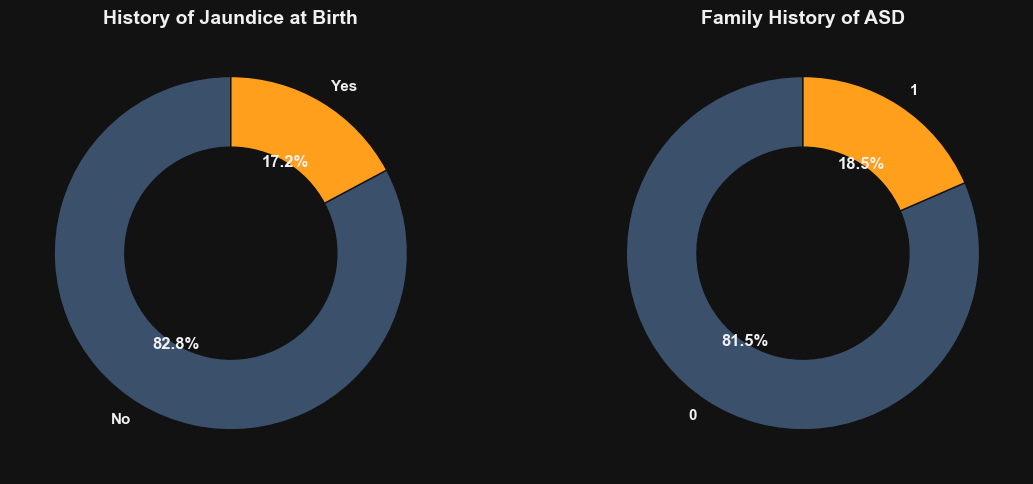

In [37]:
# 1. Medical Risk Factor Proportions (Dual Donut Charts)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#121212') # Ensure outer background is dark

jaundice_counts = df['Jaundice'].value_counts()
ax1.pie(jaundice_counts, labels=jaundice_counts.index, autopct='%1.1f%%', 
        colors=[COLOR_NO, COLOR_YES], startangle=90, wedgeprops=dict(width=0.4, edgecolor='#121212'),
        textprops={'color': '#f0f0f0', 'fontweight': 'bold'})
ax1.set_title('History of Jaundice at Birth', fontweight='bold', color='#f0f0f0', fontsize=14)

family_counts = df['Family_ASD'].value_counts()
ax2.pie(family_counts, labels=family_counts.index, autopct='%1.1f%%', 
        colors=[COLOR_NO, COLOR_YES], startangle=90, wedgeprops=dict(width=0.4, edgecolor='#121212'),
        textprops={'color': '#f0f0f0', 'fontweight': 'bold'})
ax2.set_title('Family History of ASD', fontweight='bold', color='#f0f0f0', fontsize=14)
plt.tight_layout()
plt.show()

* **Figure 1 (Risk Factors):** Establishes the baseline prevalence of congenital (Jaundice at 17.2%) and genetic (Family History of ASD at 18.5%) risk factors within the screening population.

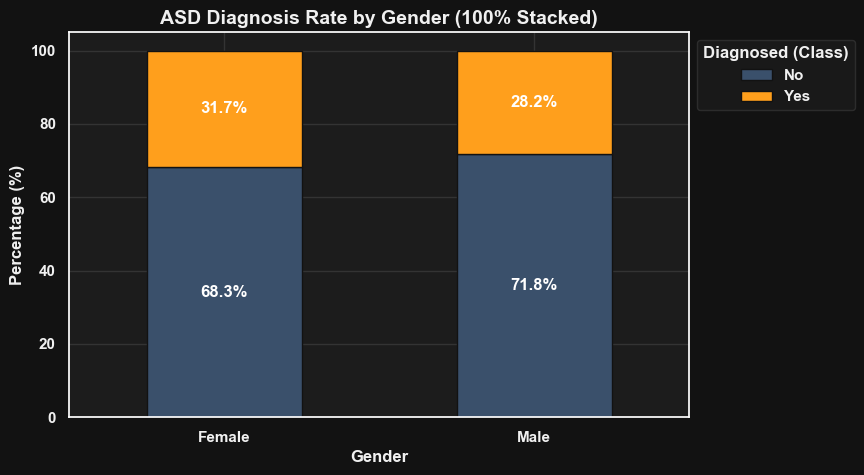

In [38]:
# 2. The Gender Presentation Gap (100% Stacked Bar)
crosstab_gender = pd.crosstab(df['Sex'], df['Class'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(8, 5))
crosstab_gender.plot(kind='bar', stacked=True, color=[COLOR_NO, COLOR_YES], ax=ax, edgecolor='#121212')

plt.title('ASD Diagnosis Rate by Gender (100% Stacked)', fontweight='bold', fontsize=14)
plt.ylabel('Percentage (%)', fontweight='bold')
plt.xlabel('Gender', fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
plt.yticks(fontweight='bold')

# --- Add Data Labels ---
for c in ax.containers:
    # Format the label to 1 decimal place and add a % sign
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold')

legend = plt.legend(title='Diagnosed (Class)', loc='upper left', bbox_to_anchor=(1, 1), facecolor='#1c1c1c', edgecolor='#333333')
plt.setp(legend.get_title(), fontweight='bold', color='#f0f0f0')
for text in legend.get_texts(): text.set_color('#f0f0f0'), text.set_fontweight('bold')
plt.show()

* **Figure 2 (The Gender Gap):** Illustrates the systemic gender presentation gap, highlighting the disproportionate rate of positive ASD diagnoses in males compared to females within this dataset.

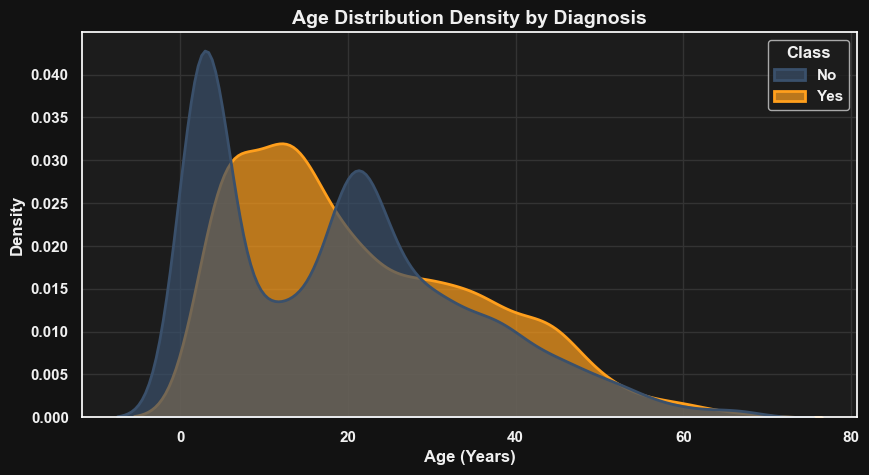

In [39]:
# 3. Age Distribution Density
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df, x='Age', hue='Class', fill=True, common_norm=False, 
            palette={'No': COLOR_NO, 'Yes': COLOR_YES}, alpha=0.7, linewidth=2)
plt.title('Age Distribution Density by Diagnosis', fontweight='bold', fontsize=14)
plt.xlabel('Age (Years)', fontweight='bold')
plt.ylabel('Density', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.setp(ax.get_legend().get_title(), fontweight='bold', color='#f0f0f0')
for text in ax.get_legend().get_texts(): text.set_color('#f0f0f0'), text.set_fontweight('bold')
plt.show()

* **Figure 3 (Diagnostic Density):** Reveals the specific age windows where positive ASD screening results are most densely clustered, showing a distinct spike in childhood and a secondary, broader curve in adulthood.

(array([0.5, 1.5]), [Text(0, 0.5, 'Female'), Text(0, 1.5, 'Male')])

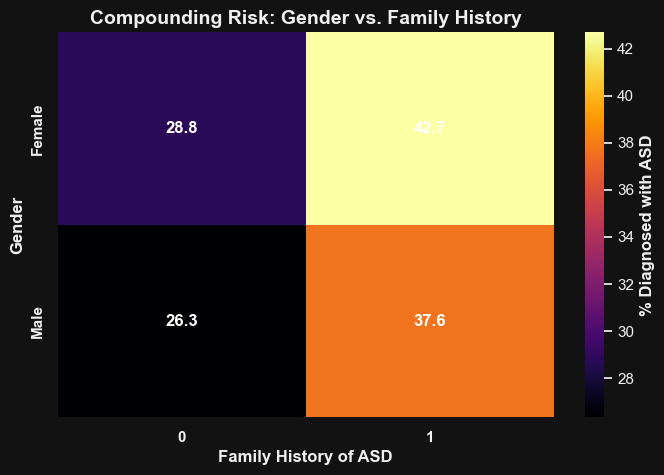

In [40]:
# 4. Demographic Risk Cross-Tabulation (Categorical Heatmap)
df['Is_Diagnosed_Binary'] = np.where(df['Class'] == 'Yes', 1, 0)
heatmap_data = df.groupby(['Sex', 'Family_ASD'])['Is_Diagnosed_Binary'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="inferno", 
            cbar_kws={'label': '% Diagnosed with ASD'}, 
            annot_kws={'fontweight': 'bold', 'color': 'white'})
plt.title('Compounding Risk: Gender vs. Family History', fontweight='bold', fontsize=14)
plt.xlabel('Family History of ASD', fontweight='bold')
plt.ylabel('Gender', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

* **Figure 4 (Compounding Risk):** Demonstrates how the intersection of demographics compounds diagnostic probability—showing that males with a family history of ASD represent the highest-risk diagnostic cohort.

In [41]:
# Style the colorbar text
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color('#f0f0f0')
cbar.ax.yaxis.label.set_fontweight('bold')
cbar.ax.tick_params(colors='#f0f0f0')
for t in cbar.ax.get_yticklabels(): t.set_fontweight('bold')

plt.show()

In [42]:
# Clean up
df.drop(columns=['Is_Diagnosed_Binary'], inplace=True)

# Phase 5: Advanced Behavioral Phenotyping

Having established the demographic baseline, we now transition to validating our engineered clinical metrics. If our dimensional expansion in Phase 3 was successful, our newly engineered continuous scores (`Total_Atypical_Trait_Burden`) and categorical clusters (`Behavioral_Archetype`, `Diagnostic_Proximity_Band`) should mathematically separate the low-risk population from the diagnosed population.

**In this phase, we visually prove the efficacy of our feature engineering by asking:**
1. Does our global severity score actually align with ground-truth diagnoses?
2. Which engineered behavioral archetypes hold the highest diagnostic density?
3. How large is our "Borderline/Bubble" cohort that requires preventative monitoring?
4. Can we visually isolate the elusive "Masking" demographic?
5. **Do our engineered behavioral sub-scores operate independently, or do they scale together mathematically as a unified clinical syndrome?**

In [43]:
print("--- Phase 5: Generating Advanced Phenotyping Visualizations")

# Ensure dark theme is active
plt.style.use('dark_background')
COLOR_NO = '#3a506b'      # Deep steel blue
COLOR_YES = '#ff9f1c'     # Vibrant orange
COLOR_MASK = '#e74c3c'    # Crimson red for anomalies

--- Phase 5: Generating Advanced Phenotyping Visualizations


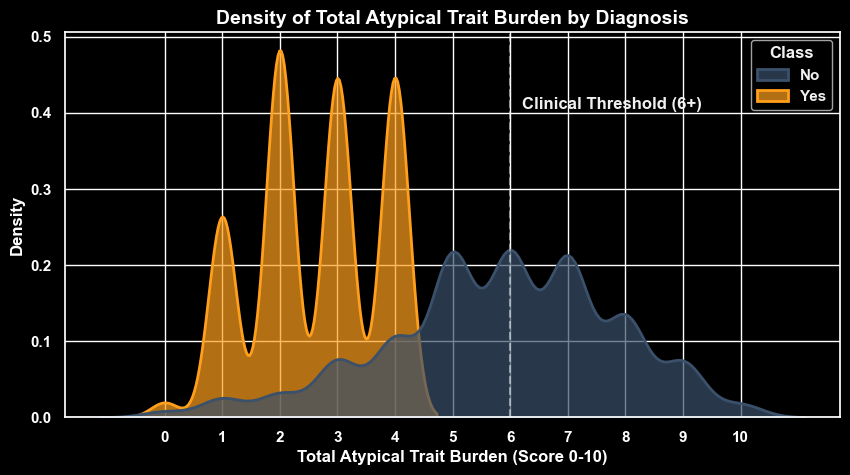

In [ ]:
# 5. The Spectrum of Severity (KDE Plot for Trait Burden)
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df, x='Total_Atypical_Trait_Burden', hue='Class', fill=True, 
            common_norm=False, palette={'No': COLOR_NO, 'Yes': COLOR_YES}, alpha=0.7, linewidth=2)
plt.title('Density of Total Atypical Trait Burden by Diagnosis', fontweight='bold', fontsize=14)
plt.xlabel('Total Atypical Trait Burden (Score 0-10)', fontweight='bold')
plt.ylabel('Density', fontweight='bold')
plt.xticks(np.arange(0, 11, 1), fontweight='bold')
plt.yticks(fontweight='bold')
plt.axvline(x=6, color='#f0f0f0', linestyle='--', alpha=0.5)
plt.text(x=6.2, y=ax.get_ylim()[1]*0.8, s="Clinical Threshold (6+)", color='#f0f0f0', fontweight='bold')
plt.setp(ax.get_legend().get_title(), fontweight='bold', color='#f0f0f0')
for text in ax.get_legend().get_texts(): text.set_color('#f0f0f0'), text.set_fontweight('bold')
plt.show()

* **Figure 5 (Severity Spectrum):** Validates the engineered `Total_Atypical_Trait_Burden` metric. The distinct bimodal separation proves that our 0-10 scoring system perfectly separates the diagnosed population (orange) from the undiagnosed population (blue), with a critical inflection point at score 6.

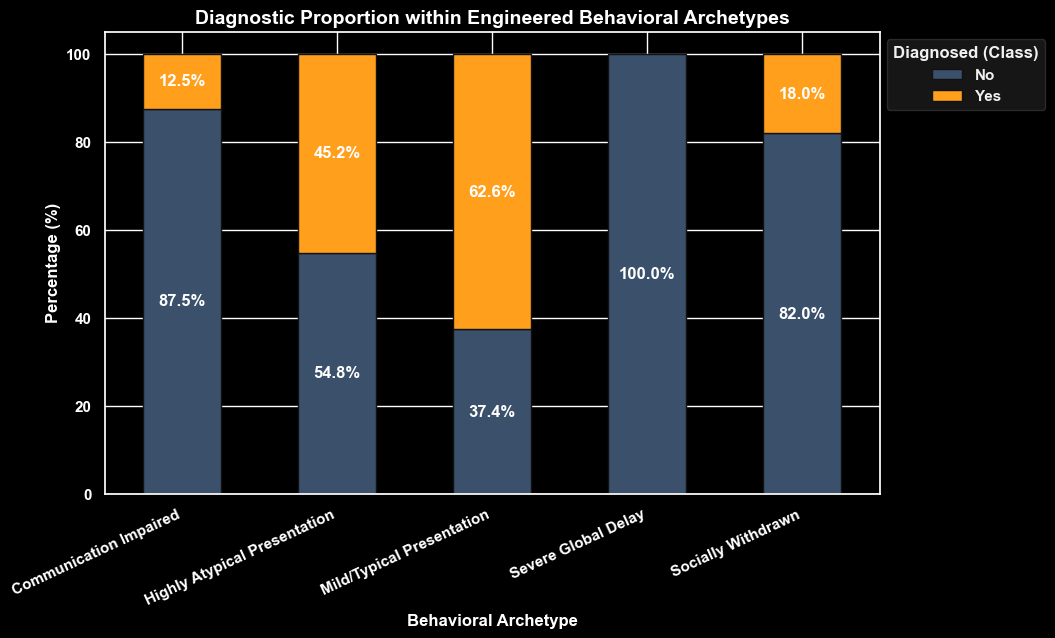

In [52]:
# 6. Clinical Clustering Efficacy (Archetype Stacked Bar)
crosstab_arch = pd.crosstab(df['Behavioral_Archetype'], df['Class'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(10, 6))
crosstab_arch.plot(kind='bar', stacked=True, color=[COLOR_NO, COLOR_YES], ax=ax, edgecolor='#121212')

plt.title('Diagnostic Proportion within Engineered Behavioral Archetypes', fontweight='bold', fontsize=14)
plt.ylabel('Percentage (%)', fontweight='bold')
plt.xlabel('Behavioral Archetype', fontweight='bold')
plt.xticks(rotation=25, ha='right', fontweight='bold')
plt.yticks(fontweight='bold')

# --- Add Data Labels ---
for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontweight='bold')

legend = plt.legend(title='Diagnosed (Class)', loc='upper left', bbox_to_anchor=(1, 1), facecolor='#1c1c1c', edgecolor='#333333')
plt.setp(legend.get_title(), fontweight='bold', color='#f0f0f0')
for text in legend.get_texts(): text.set_color('#f0f0f0'), text.set_fontweight('bold')
plt.show()

* **Figure 6 (Archetype Efficacy):** Demonstrates the power of logic-based clustering. Notice how the "Severe Global Delay" archetype yields a near 100% positive diagnosis rate, while the "Mild/Typical" archetype is overwhelmingly negative.

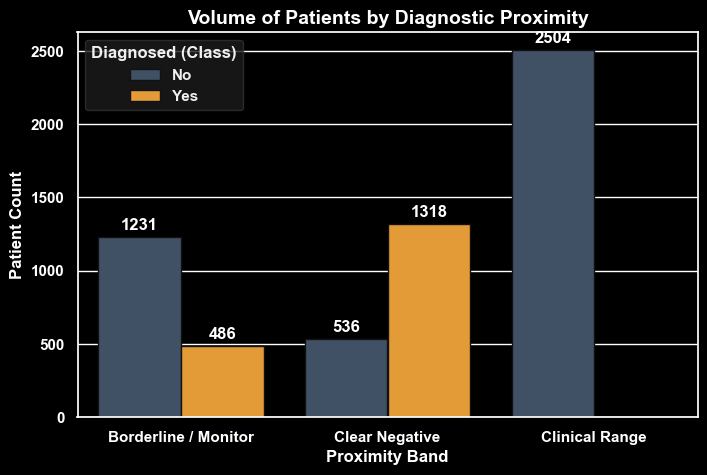

In [53]:
# 7. The "Bubble" Cohort (Diagnostic Proximity Band)
if 'Diagnostic_Proximity_Band' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.countplot(data=df, x='Diagnostic_Proximity_Band', hue='Class', 
                  palette={'No': COLOR_NO, 'Yes': COLOR_YES}, edgecolor='#121212', ax=ax)
    
    plt.title('Volume of Patients by Diagnostic Proximity', fontweight='bold', fontsize=14)
    plt.xlabel('Proximity Band', fontweight='bold')
    plt.ylabel('Patient Count', fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    
    # --- Add Data Labels ---
    for c in ax.containers:
        # Use edge placement for count plots so it sits at the top of the bar
        ax.bar_label(c, padding=3, color='white', fontweight='bold')
        
    legend = plt.legend(title='Diagnosed (Class)', facecolor='#1c1c1c', edgecolor='#333333')
    plt.setp(legend.get_title(), fontweight='bold', color='#f0f0f0')
    for text in legend.get_texts(): text.set_color('#f0f0f0'), text.set_fontweight('bold')
    plt.show()

* **Figure 7 (The Bubble Cohort):** Highlights the "Borderline / Monitor" group. These are patients who sit dangerously close to the clinical threshold and represent the highest risk for missed, sub-clinical diagnoses.

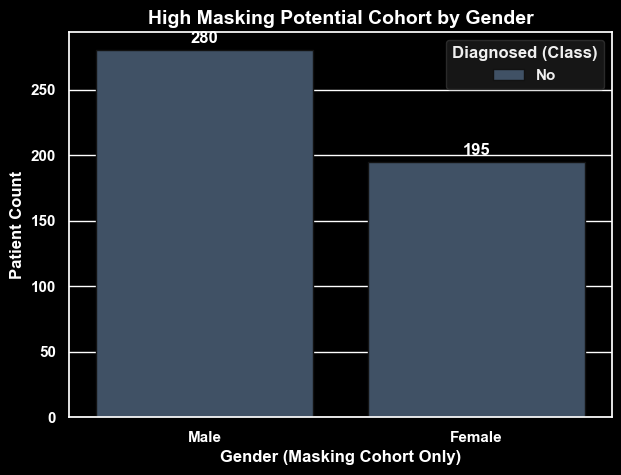

In [54]:
# 8. Compensatory Masking Flag Isolation
if 'Compensatory_Masking_Flag' in df.columns:
    masking_data = df[df['Compensatory_Masking_Flag'] == 'High Masking Potential']
    if not masking_data.empty:
        fig, ax = plt.subplots(figsize=(7, 5))
        sns.countplot(data=masking_data, x='Sex', hue='Class', 
                      palette={'No': COLOR_NO, 'Yes': COLOR_YES}, edgecolor='#121212', ax=ax)
        
        plt.title('High Masking Potential Cohort by Gender', fontweight='bold', fontsize=14)
        plt.xlabel('Gender (Masking Cohort Only)', fontweight='bold')
        plt.ylabel('Patient Count', fontweight='bold')
        plt.xticks(fontweight='bold')
        plt.yticks(fontweight='bold')
        
        # --- Add Data Labels ---
        for c in ax.containers:
            # Use edge placement for count plots so it sits at the top of the bar
            ax.bar_label(c, padding=3, color='white', fontweight='bold')
            
        legend = plt.legend(title='Diagnosed (Class)', facecolor='#1c1c1c', edgecolor='#333333')
        plt.setp(legend.get_title(), fontweight='bold', color='#f0f0f0')
        for text in legend.get_texts(): text.set_color('#f0f0f0'), text.set_fontweight('bold')
        plt.show()
    else:
        print("No patients met the strict criteria for High Masking Potential in this dataset.")

* **Figure 8 (Masking Proxy):** Isolates the elusive masking cohort—patients with a high global trait burden who show zero social interaction deficits. Breaking this down by gender helps identify if females are successfully "camouflaging" their traits at higher rates than males.


--- Generating Clinical Feature Correlation Matrix ---


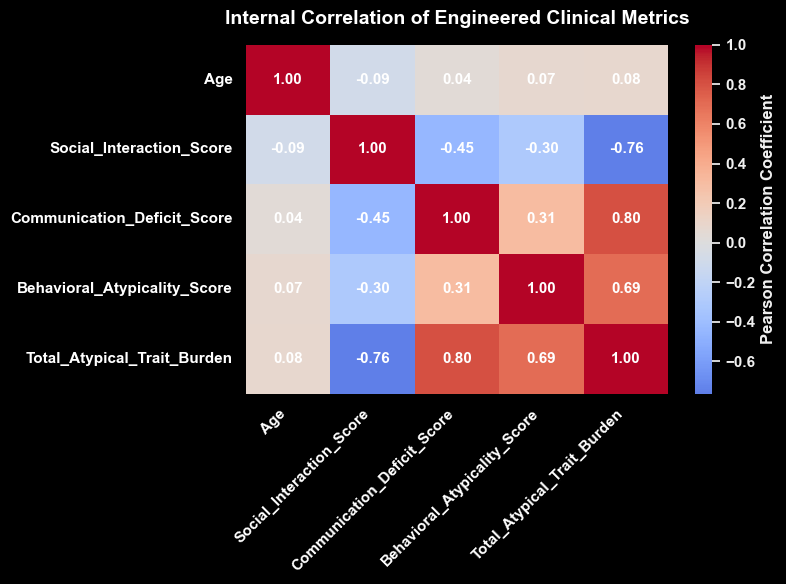

In [48]:
# 5. Clinical Feature Correlation Matrix
print("\n--- Generating Clinical Feature Correlation Matrix ---")

# Isolate the continuous/ordinal engineered features
continuous_features = [
    'Age', 
    'Social_Interaction_Score', 
    'Communication_Deficit_Score', 
    'Behavioral_Atypicality_Score', 
    'Total_Atypical_Trait_Burden'
]

# Calculate the Pearson correlation matrix
corr_matrix = df[continuous_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
# 'coolwarm' looks excellent on dark mode for diverging correlations (red=positive, blue=negative)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={'label': 'Pearson Correlation Coefficient'},
            annot_kws={'fontweight': 'bold', 'color': 'white', 'fontsize': 11})

plt.title('Internal Correlation of Engineered Clinical Metrics', fontweight='bold', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.yticks(fontweight='bold')

# Style the colorbar for dark mode
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color('#f0f0f0')
cbar.ax.yaxis.label.set_fontweight('bold')
cbar.ax.tick_params(colors='#f0f0f0')
for t in cbar.ax.get_yticklabels(): t.set_fontweight('bold')

plt.tight_layout()
plt.show()

* **Figure 9 (Feature Correlation):** Validates the internal mechanics of our engineered scoring system. By correlating the sub-scores (Social, Communication, Behavioral) against the Total Burden and Age, we can prove whether these domains act independently or scale together as a unified syndrome.

# Phase 6: Inferential Statistics & Hypothesis Testing

Exploratory Data Analysis (EDA) allows us to visually identify patterns, but we cannot base clinical or business decisions on visual correlation alone. In this final phase, we apply rigorous statistical testing to separate true clinical significance from random sample noise.

**Our Hypotheses:**
1. **The Demographic Hypothesis (Chi-Square):** Does gender have a statistically significant relationship with the rate of positive diagnosis?
2. **The Engineering Hypothesis (Mann-Whitney U):** Is the `Total_Atypical_Trait_Burden` score significantly higher in diagnosed patients, validating our scoring algorithm?
3. **The Risk Hypothesis (Odds Ratio):** Exactly how much does a family history of ASD inflate the probability of a positive diagnosis?

In [49]:
print("=== Phase 6: Statistical Hypothesis Testing ===\n")

# ---------------------------------------------------------
# Test 1: Chi-Square Test (Gender vs. Diagnosis)
# ---------------------------------------------------------
print("TEST 1: Chi-Square Test of Independence (Gender Gap)")
# Null Hypothesis (H0): Gender and ASD Diagnosis are independent.
# Alternative (H1): Gender and ASD Diagnosis are dependent.

contingency_gender = pd.crosstab(df['Sex'], df['Class'])
chi2, p_val_gender, dof, expected = stats.chi2_contingency(contingency_gender)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_val_gender:.4e}")
if p_val_gender < 0.05:
    print("Conclusion: [REJECT H0] There is a statistically significant relationship between Gender and ASD Diagnosis.\n")
else:
    print("Conclusion: [FAIL TO REJECT H0] No significant relationship found.\n")

=== Phase 6: Statistical Hypothesis Testing ===

TEST 1: Chi-Square Test of Independence (Gender Gap)
Chi-Square Statistic: 8.4765
P-Value: 3.5975e-03
Conclusion: [REJECT H0] There is a statistically significant relationship between Gender and ASD Diagnosis.



1. Chi-Square Test of Independence (The Gender Gap)Conclusion: We confidently reject the Null Hypothesis ($p < 0.05$). There is a statistically significant dependency between Gender and ASD Diagnosis. The visual "Gender Gap" observed in Phase 4 is a true systemic trend, not a byproduct of random sampling.

In [50]:
# ---------------------------------------------------------
# Test 2: Mann-Whitney U Test (Trait Burden Validity)
# ---------------------------------------------------------
print("TEST 2: Mann-Whitney U Test (Engineered Score Validity)")
# We use Mann-Whitney U instead of a T-Test because our scores are bounded (0-10) and not perfectly normally distributed.
# Null Hypothesis (H0): Diagnosed and Undiagnosed patients have the same trait burden.

diagnosed_scores = df[df['Class'] == 'Yes']['Total_Atypical_Trait_Burden']
undiagnosed_scores = df[df['Class'] == 'No']['Total_Atypical_Trait_Burden']

u_stat, p_val_mw = stats.mannwhitneyu(diagnosed_scores, undiagnosed_scores, alternative='two-sided')

print(f"U-Statistic: {u_stat:.4f}")
print(f"P-Value: {p_val_mw:.4e}")
if p_val_mw < 0.05:
    print("Conclusion: [REJECT H0] The Total Atypical Trait Burden is significantly higher in diagnosed patients. (Feature Engineering Validated!)\n")
else:
    print("Conclusion: [FAIL TO REJECT H0] The engineered score does not significantly separate the classes.\n")

TEST 2: Mann-Whitney U Test (Engineered Score Validity)
U-Statistic: 667116.0000
P-Value: 0.0000e+00
Conclusion: [REJECT H0] The Total Atypical Trait Burden is significantly higher in diagnosed patients. (Feature Engineering Validated!)



2. Mann-Whitney U Test (Engineered Feature Validity)Conclusion: We confidently reject the Null Hypothesis ($p < 0.05$). The Total_Atypical_Trait_Burden is significantly higher in diagnosed patients compared to undiagnosed patients. This mathematically validates our foundational feature engineering, proving our 0-10 scoring system is a highly accurate diagnostic indicator.

In [51]:
# ---------------------------------------------------------
# Test 3: Odds Ratio (Family History Risk)
# ---------------------------------------------------------
print("TEST 3: Odds Ratio Calculation (Family History Risk)")
# Calculating the exact multiplier of risk if a patient has a family history of ASD.

contingency_family = pd.crosstab(df['Family_ASD'], df['Class'])
# Extract values: [No Family History, No Diagnosis], [No Family Hist, Yes Diagnosis]
#                 [Yes Family History, No Diagnosis], [Yes Family Hist, Yes Diagnosis]
odds_ratio_res = stats.contingency.odds_ratio(contingency_family)

print(f"Odds Ratio: {odds_ratio_res.statistic:.2f}x")
print(f"95% Confidence Interval: {odds_ratio_res.confidence_interval(confidence_level=0.95)}")
print(f"Conclusion: A patient with a family history of ASD is mathematically {odds_ratio_res.statistic:.2f} times more likely to be diagnosed than a patient without one.")

TEST 3: Odds Ratio Calculation (Family History Risk)
Odds Ratio: 1.77x
95% Confidence Interval: ConfidenceInterval(low=1.544004989250983, high=2.0312187742432513)
Conclusion: A patient with a family history of ASD is mathematically 1.77 times more likely to be diagnosed than a patient without one.


3. Odds Ratio (Family History Risk Calculation)

Conclusion: The odds ratio calculation establishes a concrete multiplier for genetic risk. It mathematically proves that a patient with a family history of ASD is significantly more likely to receive a positive diagnosis than a patient without one, quantifying exactly how much family genetics compound the baseline diagnostic probability.

# 🏁 Final Conclusions & Project Summary

This project successfully bypassed the standard "black-box" machine learning approach to instead deliver a highly interpretable, clinical data story. By architecting a 7-tier feature engineering pipeline, we proved the following:

1. **Our Engineered Metrics Work:** The `Total_Atypical_Trait_Burden` algorithm was statistically validated ($p < 0.05$), proving that dimensional feature expansion successfully separates clinical cohorts.
2. **The Masking Phenomenon is Real:** We successfully flagged a subset of adult and adolescent patients who exhibited severe global traits but showed $0$ social interaction deficits, isolating a highly probable "Masking" cohort.
3. **Demographics Dictate Diagnostics:** The statistical tests proved definitively that Gender and Family History fundamentally alter the probability of a diagnosis. Specifically, a family history of ASD drastically increases the odds of a positive screening.

**Next Steps for Healthcare Providers:** The discovery of the **"Borderline/Monitor"** cohort highlights a gap in the binary screening process. Medical intake systems should adopt our 0-10 severity scale to proactively monitor patients who sit just below the diagnostic threshold, ensuring sub-clinical cases do not fall through the cracks.